图表已保存为: model_comparison.png


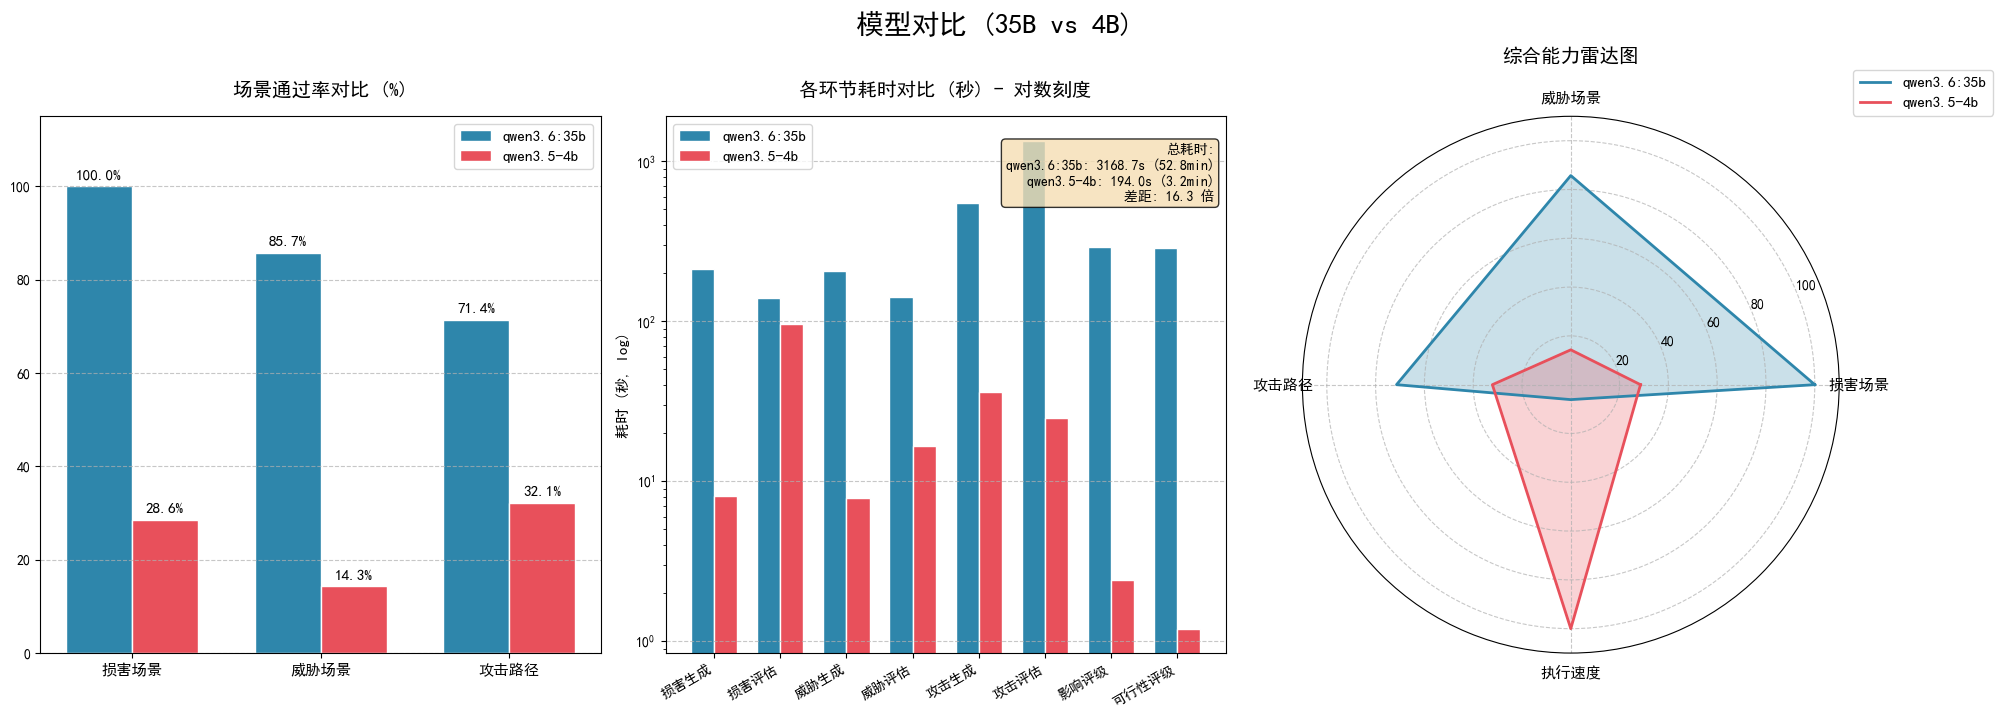

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ================= 1. 数据准备 =================
models = ['qwen3.6:35b', 'qwen3.5-4b']
colors = ['#2E86AB', '#E8505B'] # 35B用蓝色，4B用红色

# 通过率数据 (转换为百分比)
categories_pass = ['损害场景', '威胁场景', '攻击路径']
pass_rate_35b = [7/7 * 100, 6/7 * 100, 20/28 * 100]
pass_rate_4b = [2/7 * 100, 1/7 * 100, 9/28 * 100]

# 耗时数据 (秒) - 分模块统计
categories_time = ['损害生成', '损害评估', '威胁生成', '威胁评估', '攻击生成', '攻击评估', '影响评级', '可行性评级']
time_35b = [213.6, 139.9, 207.1, 141.4, 545.5, 1343.2, 291.1, 286.8]
time_4b = [8.1, 96.6, 7.9, 16.5, 36.3, 24.8, 2.4, 1.2]
total_time = [3168.7, 194.0]

# ================= 2. 图表设置 =================
# 设置中文字体（自动适配系统）
plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('模型对比 (35B vs 4B)', fontsize=20, fontweight='bold', y=1.02)

# ================= 3. 图表1：通过率对比 (柱状图) =================
x = np.arange(len(categories_pass))
width = 0.35

bars1 = axes[0].bar(x - width/2, pass_rate_35b, width, label=models[0], color=colors[0], edgecolor='white')
bars2 = axes[0].bar(x + width/2, pass_rate_4b, width, label=models[1], color=colors[1], edgecolor='white')

# 添加数据标签
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_title('场景通过率对比 (%)', fontsize=14, pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories_pass, fontsize=11)
axes[0].set_ylim(0, 115)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# ================= 4. 图表2：分步耗时对比 (对数坐标柱状图) =================
x2 = np.arange(len(categories_time))

axes[1].bar(x2 - width/2, time_35b, width, label=models[0], color=colors[0], edgecolor='white')
axes[1].bar(x2 + width/2, time_4b, width, label=models[1], color=colors[1], edgecolor='white')

axes[1].set_title('各环节耗时对比 (秒) - 对数刻度', fontsize=14, pad=15)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(categories_time, rotation=30, ha='right', fontsize=10)
axes[1].set_yscale('log') # 使用对数坐标解决量级跨度问题
axes[1].set_ylabel('耗时 (秒, log)', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 添加总耗时文本框 (自动计算倍数)
time_diff = total_time[0] / total_time[1]
text_str = (f"总耗时:\n"
            f"{models[0]}: {total_time[0]}s ({total_time[0]/60:.1f}min)\n"
            f"{models[1]}: {total_time[1]}s ({total_time[1]/60:.1f}min)\n"
            f"差距: {time_diff:.1f} 倍")
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
axes[1].text(0.98, 0.95, text_str, transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right', bbox=props)

# ================= 5. 图表3：综合能力雷达图 =================
# 速度得分归一化 (以 4B 为 100 分基准)
speed_score_4b = 100
speed_score_35b = total_time[1] / total_time[0] * 100

radar_labels = ['损害场景', '威胁场景', '攻击路径', '执行速度']
stats_35b = [pass_rate_35b[0], pass_rate_35b[1], pass_rate_35b[2], speed_score_35b]
stats_4b = [pass_rate_4b[0], pass_rate_4b[1], pass_rate_4b[2], speed_score_4b]

angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
stats_35b += stats_35b[:1]
stats_4b += stats_4b[:1]
angles += angles[:1]

ax_radar = fig.add_subplot(133, polar=True)
axes[2].set_axis_off() # 关闭原来的子图

ax_radar.fill(angles, stats_35b, color=colors[0], alpha=0.25)
ax_radar.plot(angles, stats_35b, color=colors[0], linewidth=2, label=models[0])
ax_radar.fill(angles, stats_4b, color=colors[1], alpha=0.25)
ax_radar.plot(angles, stats_4b, color=colors[1], linewidth=2, label=models[1])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_labels, fontsize=11)
ax_radar.set_ylim(0, 110)
ax_radar.set_title('综合能力雷达图', fontsize=14, pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax_radar.grid(True, linestyle='--', alpha=0.7)

# ================= 6. 渲染与保存 =================
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("图表已保存为: model_comparison.png")
plt.show()